# 🚗 Analysis of the 10-Vehicle Emissions Experiment

This notebook consolidates the full analysis used in the article, covering pipeline performance, LLM behavior, energy consumption, emissions, and statistical validation across the three SLMs. ✨

## 📥 Inputs

- `data/processed/emissions/<model>/<vehicle>_emissions.csv`
- `data/processed/codecarbon/<model>_<vehicle>_emissions.csv`

## 📤 Outputs

- consolidated dataframe saved to `outputs/reports/df_all.csv`
- figures saved to `outputs/figures/`
- reports saved to `outputs/reports/`

## 🧭 What This Notebook Covers

- data loading and consistency checks
- execution-time, CPU, and memory analysis across pipeline components
- token, latency, and throughput analysis for the evaluated SLMs
- aligned energy and emissions analysis with CodeCarbon
- statistical validation and article-ready summary tables

## 📌 Repository Paths

All paths are resolved from the repository root with `pathlib.Path`, so the notebook can run from either the project root or the `notebooks/` directory.


In [52]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "data").exists():
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from helpers.emissions_stats import (
    DEFAULT_CONFIG,
    build_aligned_plot_data,
    compare_results_to_reference,
    reconstruct_stats_table,
    reference_stats_table,
)
from helpers.statistical_analysis import (
    aggregate_metric_by_block,
    cliffs_delta,
    friedman_test,
    kruskal_wallis_test,
    pairwise_dunn_tests,
    pairwise_wilcoxon_tests,
    shapiro_tests_by_model,
)

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_PROCESSED_DIR = REPO_ROOT / "data" / "processed"
PRIMARY_EMISSIONS_DIR = DATA_PROCESSED_DIR / "emissions"
CODECARBON_DIR = DATA_PROCESSED_DIR / "codecarbon"
EMISSIONS_DIR = PRIMARY_EMISSIONS_DIR
OUTPUTS_FIGURES_DIR = REPO_ROOT / "outputs" / "figures"
OUTPUTS_REPORTS_DIR = REPO_ROOT / "outputs" / "reports"
DF_ALL_PATH = OUTPUTS_REPORTS_DIR / "df_all.csv"

for directory in (OUTPUTS_FIGURES_DIR, OUTPUTS_REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)


## 📦 Data Loading

This section loads the processed experiment files and prepares the aligned per-inference dataframe used in the environmental analyses.


In [53]:
MODELS = ["gemma", "qwen", "smollm2"]

print("Primary emissions dir:", PRIMARY_EMISSIONS_DIR)
print("CodeCarbon dir:", CODECARBON_DIR)
print("Default config:", DEFAULT_CONFIG)


Primary emissions dir: /Users/morsinaldo/Developer/mmcloud-agent-development/data/processed/emissions
CodeCarbon dir: /Users/morsinaldo/Developer/mmcloud-agent-development/data/processed/codecarbon
Default config: LegacySourceConfig(llm_snapshot_dir=PosixPath('data/processed/emissions'), codecarbon_dir=PosixPath('data/processed/codecarbon'))


In [54]:
all_dfs = []

for model in MODELS:
    for csv_path in sorted((PRIMARY_EMISSIONS_DIR / model).glob("*.csv")):
        vehicle = csv_path.stem.replace("_emissions", "")
        df = pd.read_csv(csv_path, low_memory=False)
        df["model"] = model
        df["vehicle"] = vehicle
        all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)
df_all.to_csv(DF_ALL_PATH, index=False)

print(df_all.shape)
df_all.head()


(18786, 160)


,row_id,ts,Unnamed: 0.1,Unnamed: 0,timestamp,speed,rpm,engine_load,coolant_temp,timing_advance,intake_temp,throttle,fuel_level,latitude,longitude,accel_x,accel_y,accel_z,driver_behavior,teda_flag,teda_inference_time,fuel_type,fuel_type_prob,fuel_type_inference_time,mmcloud_inference_time,eco,tipoVia,tipoVia_prob,city_highway_inference_time,instant_fuel_consumption,distancia,consumo_total,consumo_medio,notaImetro,tempAmbiente,radar_area,temp_rasp,radar_area_original,has_acidente,has_multa,ground_truth,_ts_float,maf,road_type,gyro_z_dps,gyro_x,gyro_y,gyro_z,accel_magnitude,city_highway_int,city_highway_prob,city_highway,maf_estimated,co2_emission,co2_emission_per_km,total_distance,total_consumption,consumption_count,average_consumption,heading,m.teda.run.ok,m.teda.run.wall_ms,m.teda.run.cpu_user_s,m.teda.run.cpu_sys_s,m.teda.run.thread_cpu_s,m.teda.run.rss_mb,m.teda.run.mem_pct,m.mmcloud.process_point.ok,m.mmcloud.process_point.wall_ms,m.mmcloud.process_point.cpu_user_s,m.mmcloud.process_point.cpu_sys_s,m.mmcloud.process_point.thread_cpu_s,m.mmcloud.process_point.rss_mb,m.mmcloud.process_point.mem_pct,m.rf.fuel_type.ok,m.rf.fuel_type.wall_ms,m.rf.fuel_type.cpu_user_s,m.rf.fuel_type.cpu_sys_s,m.rf.fuel_type.thread_cpu_s,m.rf.fuel_type.rss_mb,m.rf.fuel_type.mem_pct,m.rf.city_highway.ok,m.rf.city_highway.wall_ms,m.rf.city_highway.cpu_user_s,m.rf.city_highway.cpu_sys_s,m.rf.city_highway.thread_cpu_s,m.rf.city_highway.rss_mb,m.rf.city_highway.mem_pct,policy_behavior,policy_severity,m.agent.behavior.ok,m.agent.behavior.wall_ms,m.agent.behavior.cpu_user_s,m.agent.behavior.cpu_sys_s,m.agent.behavior.thread_cpu_s,m.agent.behavior.rss_mb,m.agent.behavior.mem_pct,m.agent.safety_gps.ok,m.agent.safety_gps.wall_ms,m.agent.safety_gps.cpu_user_s,m.agent.safety_gps.cpu_sys_s,m.agent.safety_gps.thread_cpu_s,m.agent.safety_gps.rss_mb,m.agent.safety_gps.mem_pct,heading_message,orch_run_ms,orch_llm_enqueue_ms,llm_message,llm_source,llm_latency,llm_total_tokens,llm_input_tokens,llm_output_tokens,llm_total_ms_client,llm_cpu_avg_pct,llm_cpu_max_pct,llm_rss_peak_mb,llm_proc_samples,llm_proc_pid,llm_metrics_source,llm_agent_inserted_behavior_prf,model,vehicle,Device,Usuario,SessionDate,TimeSensor,Vin,Magnitude,TedaFlag,RadarArea,DriverBehaviour,CityRoadLabel,CityRoadProb,FuelType,FuelPredictionProbability,FuelModelPredictionTime(microseconds),TedaModelPredictionTime(microseconds),DriveBehaviourModelPredictionTime(microseconds),CityRoadModelPredictionTime(microseconds),TimesDisconnected,ReconnectionCount,EngineOilTemp,battery,FuelPressure,FuelRailPressure,fuel_rail_pressure,map,runtime,distance_mil,ethanol_percentage,relative_throttle,acc_pedal_d,acc_pedal_e,absolute_throttle_b,catalyst_temp_b1s1,fuel_rate,absolute_load,air_fuel_ratio,baro_pressure
0,1,2025-12-04T21:01:58.703262+00:00,0.000,0.000,2025-07-01T19:39:40.300056,0.000,871.000,32.000,70.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.275,-0.171,9.805,normal,False,0.026,Gasoline,1.000,184.443,0.000,False,Cidade,[0.62 0.38],631.524,0.000,0.000,3.021,3.021,A,28.500,139.360,59.300,139.360,False,False,nenhum,NaN,NaN,NaN,0.000,2.271,2.298,-1.581,9.810,0.000,[0.6 0.4],City,False,0.000,0.000,0.000,0.000,1,0.000,N,True,0.026,0.000,0.000,0.000,229.480,2.850,True,0.121,0.000,0.000,0.000,229.480,2.850,True,0.006,0.000,0.000,0.000,229.480,2.850,True,179.192,0.127,0.052,0.179,243.950,3.030,Cautious,low,True,0.043,0.000,0.000,0.000,243.950,3.030,True,4.020,0.004,0.000,0.004,243.950,3.030,NaN,4.340,0.031,Behavior: Cautious. PRF zone: none. Draft: Dri...,model,NaN,115.000,89.000,26.000,"6,308.000",130.908,307.500,654.141,62.000,"22,630.000",server+client,True,gemma,eclipse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2025-12-04T21:02:02.779573+00:00,1.000,1.000,2025-07-01T19:39:43.658232,0.000,871.000,32.000,70.000,0.000,0.000,16.000,97.650,0.000,0.000,-0.262,-0.105,9.727,normal,False,0.208,Gasoline,1.000,50.427

In [55]:
df_aligned_plot = build_aligned_plot_data()

print("Aligned inference rows:", len(df_aligned_plot))
print("Rows with energy values:", df_aligned_plot["energy_consumed"].notna().sum())
print("Rows with emissions values:", df_aligned_plot["emissions"].notna().sum())
df_aligned_plot[["model", "vehicle", "llm_total_ms_client", "llm_tps", "energy_consumed", "emissions"]].head()


Aligned inference rows: 2994
Rows with energy values: 2994
Rows with emissions values: 2994


,model,vehicle,llm_total_ms_client,llm_tps,energy_consumed,emissions
0,gemma,eclipse,"6,308.000",4.122,0.000,0.000
1,gemma,eclipse,"3,586.000",6.414,0.000,0.000
2,gemma,eclipse,"3,725.000",6.174,0.000,0.000
3,gemma,eclipse,"3,809.000",6.038,0.000,0.000
4,gemma,eclipse,"3,742.000",6.146,0.000,0.000


In [56]:
df_llm = df_all[df_all["llm_message"].notna()].copy()
df_no = df_all[df_all["llm_message"].isna()].copy()

print("Inference rows:", len(df_llm))
print("Inference rows with complete CodeCarbon alignment:", len(df_aligned_plot))
print("Non-inference rows:", len(df_no))


Inference rows: 2994
Inference rows with complete CodeCarbon alignment: 2994
Non-inference rows: 15792


In [57]:
df_all[["model", "vehicle"]].drop_duplicates().sort_values(["model", "vehicle"]).reset_index(drop=True)


,model,vehicle
0,gemma,eclipse
1,gemma,etios
2,gemma,fastback
3,gemma,fit
4,gemma,hb20
5,gemma,polo_silver
6,gemma,polo_white
7,gemma,prisma
8,gemma,renegade
9,gemma,tcross


In [58]:
print("Saved consolidated dataframe to:", DF_ALL_PATH)


Saved consolidated dataframe to: /Users/morsinaldo/Developer/mmcloud-agent-development/outputs/reports/df_all.csv


In [59]:
print("Figure output directory:", OUTPUTS_FIGURES_DIR)
print("Report output directory:", OUTPUTS_REPORTS_DIR)


Figure output directory: /Users/morsinaldo/Developer/mmcloud-agent-development/outputs/figures
Report output directory: /Users/morsinaldo/Developer/mmcloud-agent-development/outputs/reports


In [60]:
table_preview = reconstruct_stats_table(DEFAULT_CONFIG)
table_preview


,Metric,H,Q vs. S,G vs. Q,G vs. S,n
0,Latency,"1,596.000",0.906,-0.677,0.593,2994
1,Output tokens,513.400,0.595,-0.367,0.107,2994
2,Throughput (TPS),"1,214.300",-0.732,0.701,-0.499,2994
3,Energy,"1,413.800",0.868,-0.705,0.402,2994
4,CO2 emissions,"1,406.500",0.865,-0.702,0.405,2994


## 🔬 Analysis

The analyses below move from general dataset checks to pipeline profiling, model-level behavior, environmental footprint, and statistical validation.


In [61]:
df_all = pd.read_csv(DF_ALL_PATH)

/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/1087664954.py:1: DtypeWarning: Columns (38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(DF_ALL_PATH)


In [62]:
df_llm = df_all[df_all["llm_message"].notna()].copy()
df_no = df_all[df_all["llm_message"].isna()].copy()

print("Inference rows in main snapshot:", len(df_llm))
print("Aligned inference rows with environmental metrics:", len(df_aligned_plot))
print("Inference rows missing aligned environmental metrics:", len(df_llm) - len(df_aligned_plot))
print("Non-inference rows in main snapshot:", len(df_no))


Inference rows in main snapshot: 2994
Aligned inference rows with environmental metrics: 2994
Inference rows missing aligned environmental metrics: 0
Non-inference rows in main snapshot: 15792


In [63]:
aligned_counts = (
    df_aligned_plot.groupby(["model", "vehicle"])
    .size()
    .reset_index(name="n_aligned_inferences")
    .sort_values(["model", "vehicle"])
)

aligned_counts


,model,vehicle,n_aligned_inferences
0,gemma,eclipse,80
1,gemma,etios,107
2,gemma,fastback,86
3,gemma,fit,141
4,gemma,hb20,92
5,gemma,polo_silver,93
6,gemma,polo_white,81
7,gemma,prisma,99
8,gemma,renegade,101
9,gemma,tcross,93


In [64]:
# Preview the aligned inference rows used in the environmental analyses.

df_aligned_plot[["model", "vehicle", "inference_idx", "energy_consumed", "emissions"]].head(10)


,model,vehicle,inference_idx,energy_consumed,emissions
0,gemma,eclipse,0,0.000,0.000
1,gemma,eclipse,1,0.000,0.000
2,gemma,eclipse,2,0.000,0.000
3,gemma,eclipse,3,0.000,0.000
4,gemma,eclipse,4,0.000,0.000
5,gemma,eclipse,5,0.000,0.000
6,gemma,eclipse,6,0.000,0.000
7,gemma,eclipse,7,0.000,0.000
8,gemma,eclipse,8,0.000,0.000
9,gemma,eclipse,9,0.000,0.000


In [65]:
# Keep the main snapshot untouched. Environmental filtering is handled via df_aligned_plot.

df_all.shape


(18786, 160)

In [66]:
CPU_COL  = "thread_cpu_s"
MEM_COL  = "rss_peak_mb"
TIME_COL = "llm_total_ms_client"

# --- ML block (TEDA, MMCloud, RF) ---

def extract_block(df, prefix, block_name):
    metrics = ["wall_ms", "cpu_user_s", "cpu_sys_s", "thread_cpu_s", "rss_mb", "mem_pct"]

    data = {}
    for m in metrics:
        col = f"{prefix}{m}"
        data[m] = df[col].values if col in df.columns else np.full(len(df), np.nan)

    out = pd.DataFrame(data)
    out["block"] = block_name          # internal block label
    out["model"] = df["model"].values  # model label
    out["vehicle"] = df["vehicle"].values
    return out

df_all = pd.read_csv(DF_ALL_PATH)

df_teda    = extract_block(df_all, "m.teda.run.",              "ML_TEDA")
df_mmcloud = extract_block(df_all, "m.mmcloud.process_point.", "ML_MMCloud")
df_rf_fuel = extract_block(df_all, "m.rf.fuel_type.",          "ML_RF_fuel")
df_rf_city = extract_block(df_all, "m.rf.city_highway.",       "ML_RF_city")

df_ml = pd.concat([df_teda, df_mmcloud, df_rf_fuel, df_rf_city], ignore_index=True)

df_ml["cpu_pct"] = (
    (df_ml["cpu_user_s"] + df_ml["cpu_sys_s"]) /
    (df_ml["wall_ms"] / 1000)
) * 100
df_ml["cpu_pct"] = df_ml["cpu_pct"].clip(lower=0, upper=400)

/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/3858759186.py:21: DtypeWarning: Columns (38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(DF_ALL_PATH)


In [67]:
# Build a CPU view compatible with the other dataframes.
df_ml_cpu = df_ml.rename(columns={
    "block": "bloco",
    "model": "llm_model",
    "cpu_pct": "cpu",
})[["bloco", "llm_model", "cpu"]]

# --- AGENT Behavior ---

df_agent_behavior = pd.DataFrame({
    "bloco": "AG_Behavior",
    "llm_model": df_all["model"],
    "wall_ms": df_all["m.agent.behavior.wall_ms"],
    "cpu_user_s": df_all["m.agent.behavior.cpu_user_s"],
    "cpu_sys_s": df_all["m.agent.behavior.cpu_sys_s"],
    "thread_cpu_s": df_all["m.agent.behavior.thread_cpu_s"],
    "rss_mb": df_all["m.agent.behavior.rss_mb"],
    "mem_pct": df_all["m.agent.behavior.mem_pct"],
})

df_agent_behavior["cpu"] = (
    (df_all["m.agent.behavior.cpu_user_s"] + df_all["m.agent.behavior.cpu_sys_s"]) /
    (df_all["m.agent.behavior.wall_ms"] / 1000)
) * 100
df_agent_behavior["cpu"] = df_agent_behavior["cpu"].clip(lower=0)

# --- AGENT Safety (GPS) ---

df_agent_gps = pd.DataFrame({
    "bloco": "AG_Safety",
    "llm_model": df_all["model"],
    "wall_ms": df_all["m.agent.safety_gps.wall_ms"],
    "cpu_user_s": df_all["m.agent.safety_gps.cpu_user_s"],
    "cpu_sys_s": df_all["m.agent.safety_gps.cpu_sys_s"],
    "thread_cpu_s": df_all["m.agent.safety_gps.thread_cpu_s"],
    "rss_mb": df_all["m.agent.safety_gps.rss_mb"],
    "mem_pct": df_all["m.agent.safety_gps.mem_pct"],
})

df_agent_gps["cpu"] = (
    (df_all["m.agent.safety_gps.cpu_user_s"] + df_all["m.agent.safety_gps.cpu_sys_s"]) /
    (df_all["m.agent.safety_gps.wall_ms"] / 1000)
) * 100
df_agent_gps["cpu"] = df_agent_gps["cpu"].clip(lower=0)

# --- LLM (CPU / MEM) ---

df_llm_res = pd.DataFrame({
    "bloco": "LLM",
    "llm_model": df_all["model"],
    "cpu": df_all["llm_cpu_avg_pct"],    # já é %
    "rss_mb": df_all["llm_rss_peak_mb"],
    "cpu_max": df_all["llm_cpu_max_pct"],
})

df_llm_time = pd.DataFrame({
    "bloco": "LLM",
    "llm_model": df_all["model"],
    "time_ms": df_all["llm_total_ms_client"],   # latency in ms
})

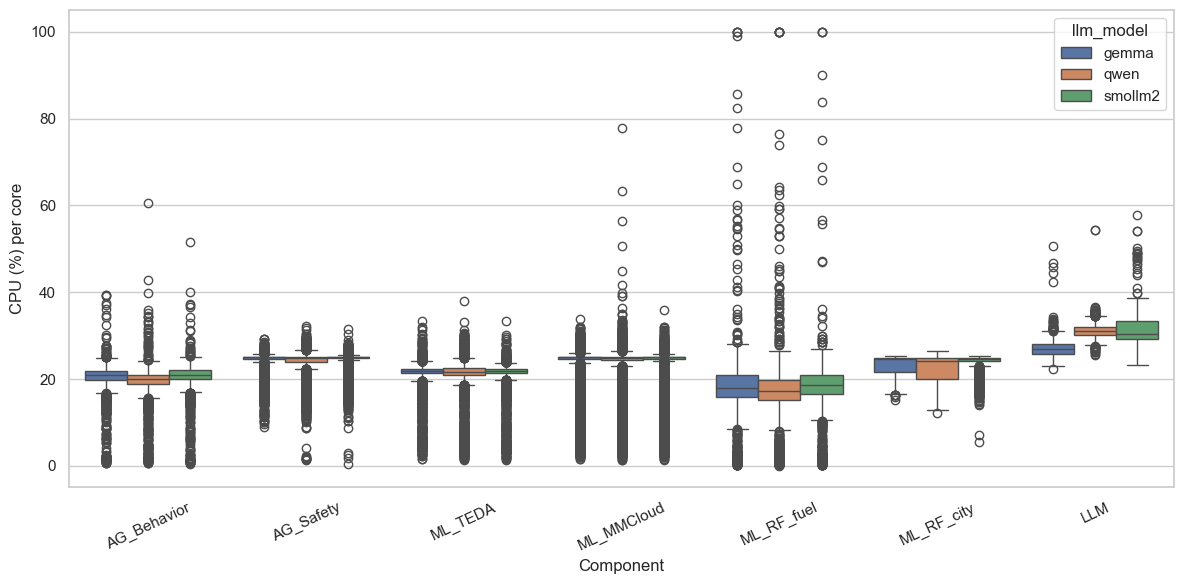

In [68]:
df_cpu_all = pd.concat([
    df_agent_behavior[["bloco","llm_model","cpu"]],
    df_agent_gps[["bloco","llm_model","cpu"]],
    df_ml_cpu[["bloco","llm_model","cpu"]],
    df_llm_res[["bloco","llm_model","cpu"]],
], ignore_index=True)

NUM_CORES = 4
df_cpu_all["cpu_normalized"] = df_cpu_all["cpu"] / NUM_CORES
df_cpu_all["cpu_normalized"] = df_cpu_all["cpu_normalized"].clip(lower=0, upper=100)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_cpu_all, x="bloco", y="cpu_normalized", hue="llm_model")
plt.xlabel("Component")
plt.ylabel("CPU (%) per core")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "cpu_pipeline_boxplot.png")
plt.show()

In [69]:
# --- Descriptive statistics below the chart ---
print("Statistical Summary of the normalized CPU(%):")
display(df_cpu_all.groupby(["bloco", "llm_model"])["cpu_normalized"].describe())

Statistical Summary of the normalized CPU(%):


count   mean   std    min    25%    50%    75%     max
bloco       llm_model                                                           
AG_Behavior gemma     6,262.000 20.661 2.460  0.571 19.811 20.930 21.875  39.286
            qwen      6,262.000 19.673 2.813  0.561 18.817 19.922 21.000  60.526
            smollm2   6,262.000 20.795 2.367  0.495 20.000 21.053 22.059  51.667
AG_Safety   gemma     6,262.000 24.304 1.945  9.061 24.626 25.010 25.065  29.263
            qwen      6,262.000 23.885 2.778  1.418 24.005 24.943 25.094  32.163
            smollm2   6,262.000 24.454 1.842  0.454 24.766 25.015 25.064  31.570
LLM         gemma       973.000 27.248 2.359 22.396 25.887 26.839 27.978  50.715
            qwen      1,060.000 31.269 2.026 25.523 30.193 30.990 31.931  54.364
            smollm2     961.000 31.376 3.645 23.182 29.165 30.489 33.327  57.880
ML_MMCloud  gemma     6,262.000 22.859 5.763  1.502 24.544 25.000 25.148  33.747
            qwen      6,262.000 22.627 6.397  1.380 24.317 24.936 25.172  77.744
            smollm2   6,262.000 23.704 4.416  1.336 24.721 25.000 25.125  35.989
ML_RF_city  gemma     6,262.000 23.341 2.215 15.082 21.538 24.628 24.885  25.284
            qwen      6,262.000 22.532 2.692 12.256 20.064 24.217 24.906  26.371
            smollm2   6,262.000 23.711 2.150  5.547 24.135 24.726 24.927  25.263
ML_RF_fuel  gemma     6,262.000 17.900 5.662  0.164 15.909 17.857 20.833 100.000
            qwen      6,262.000 17.015 6.180  0.073 15.201 17.308 19.872 100.000
            smollm2   6,262.000 18.512 4.927  0.132 16.667 18.750 20.833 100.000
ML_TEDA     gemma     6,262.000 21.409 2.922  1.578 21.305 21.774 22.414  33.364
            qwen      6,262.000 21.311 3.210  1.439 20.988 21.637 22.557  37.987
            smollm2   6,262.000 21.441 2.639  1.335 21.303 21.756 22.307  33.333

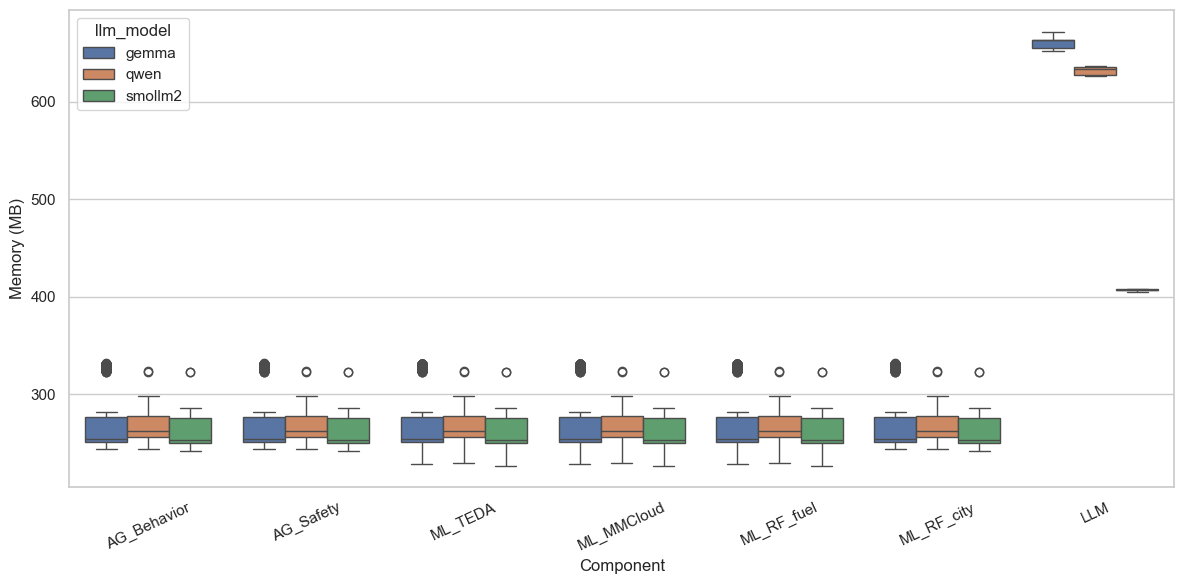

In [70]:
# Compatible ML block view for memory.
df_ml_mem = df_ml.rename(columns={
    "block": "bloco",
    "model": "llm_model",
})[["bloco", "llm_model", "rss_mb"]]

df_mem_all = pd.concat([
    df_agent_behavior[["bloco","llm_model","rss_mb"]],
    df_agent_gps[["bloco","llm_model","rss_mb"]],
    df_ml_mem[["bloco","llm_model","rss_mb"]],
    df_llm_res[["bloco","llm_model","rss_mb"]],  # memória do LLM
], ignore_index=True)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_mem_all, x="bloco", y="rss_mb", hue="llm_model")
plt.xlabel("Component")
plt.ylabel("Memory (MB)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "memory_pipeline_boxplot.png")
plt.show()

In [71]:
# --- Descriptive statistics below the chart ---
print("Statistical Summary of the memory (RSS MB):")
display(df_mem_all.groupby(["bloco", "llm_model"])["rss_mb"].describe())

Statistical Summary of the memory (RSS MB):


count    mean    std     min     25%     50%     75%     max
bloco       llm_model                                                                 
AG_Behavior gemma     6,262.000 266.377 23.674 243.360 250.595 253.620 276.300 331.660
            qwen      6,262.000 267.035 13.032 243.770 256.022 262.710 277.700 323.860
            smollm2   6,262.000 261.508 13.474 241.410 249.940 252.770 275.810 323.160
AG_Safety   gemma     6,262.000 266.377 23.674 243.360 250.595 253.620 276.300 331.660
            qwen      6,262.000 267.036 13.032 243.770 256.022 262.710 277.700 323.860
            smollm2   6,262.000 261.508 13.474 241.410 249.940 252.770 275.810 323.160
LLM         gemma       973.000 661.760  4.701 652.703 655.312 663.469 663.984 672.047
            qwen      1,060.000 632.558  3.575 626.688 627.703 633.688 635.703 636.703
            smollm2     961.000 407.218  0.671 405.125 406.625 407.406 407.766 408.422
ML_MMCloud  gemma     6,262.000 266.312 23.702 228.450 250.590 253.610 276.280 331.480
            qwen      6,262.000 266.975 13.100 228.980 255.980 262.690 277.697 323.860
            smollm2   6,262.000 261.455 13.523 226.770 249.910 252.750 275.810 323.160
ML_RF_city  gemma     6,262.000 266.377 23.674 243.360 250.595 253.620 276.300 331.660
            qwen      6,262.000 267.035 13.032 243.770 256.022 262.710 277.700 323.860
            smollm2   6,262.000 261.508 13.474 241.410 249.940 252.770 275.810 323.160
ML_RF_fuel  gemma     6,262.000 266.312 23.702 228.450 250.590 253.610 276.280 331.480
            qwen      6,262.000 266.975 13.100 228.980 255.980 262.690 277.697 323.860
            smollm2   6,262.000 261.455 13.523 226.770 249.910 252.750 275.810 323.160
ML_TEDA     gemma     6,262.000 266.312 23.702 228.450 250.590 253.610 276.280 331.480
            qwen      6,262.000 266.975 13.100 228.980 255.980 262.690 277.697 323.860
            smollm2   6,262.000 261.455 13.523 226.770 249.910 252.750 275.810 323.160

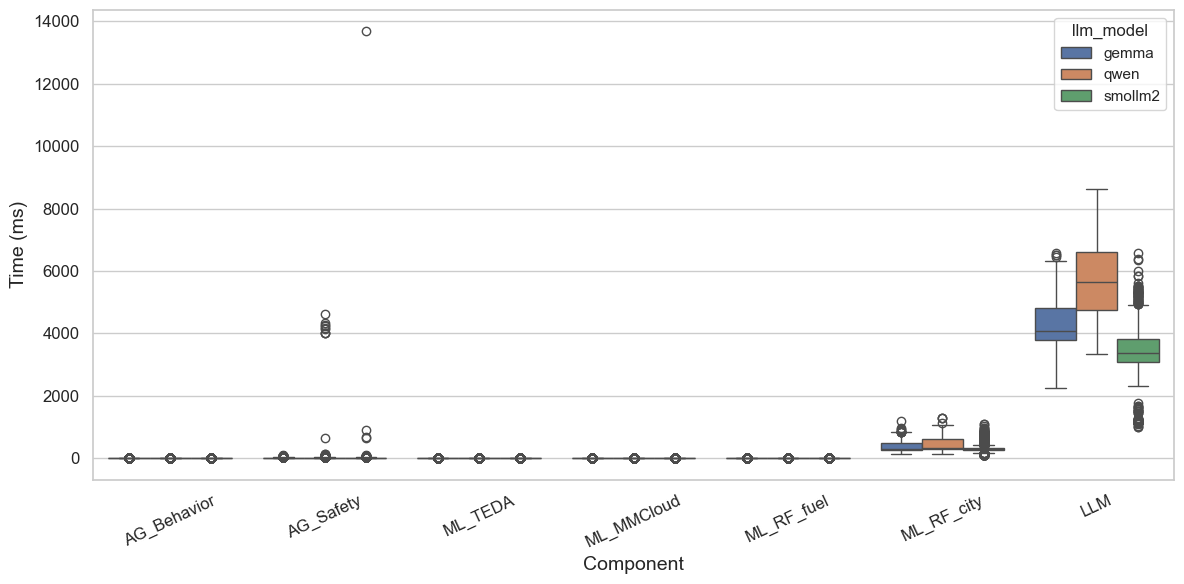

In [72]:
# --- ML block (rename to match agent blocks) ---
df_ml_time = df_ml.rename(columns={
    "block": "bloco",
    "model": "llm_model",
})[["bloco", "llm_model", "wall_ms"]].rename(columns={"wall_ms": "time_ms"})

# --- Merge all agent + ML blocks (time) ---
df_time_parts = pd.concat([
    df_agent_behavior[["bloco","llm_model","wall_ms"]].rename(columns={"wall_ms":"time_ms"}),
    df_agent_gps[["bloco","llm_model","wall_ms"]].rename(columns={"wall_ms":"time_ms"}),
    df_ml_time[["bloco","llm_model","time_ms"]],
], ignore_index=True)

# --- Add LLM latency block (df_llm_time was defined earlier) ---
df_time_all = pd.concat([
    df_time_parts,
    df_llm_time[["bloco","llm_model","time_ms"]],
], ignore_index=True)

# --- Plot ---
plt.figure(figsize=(12,6))
ax = sns.boxplot(data=df_time_all, x="bloco", y="time_ms", hue="llm_model")
ax.set_xlabel("Component", fontsize=14)
ax.set_ylabel("Time (ms)", fontsize=14)
ax.tick_params(axis="x", labelsize=12, rotation=25)
ax.tick_params(axis="y", labelsize=12)
ax.legend(title="llm_model", title_fontsize=12, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "time_pipeline_boxplot.png")
plt.show()

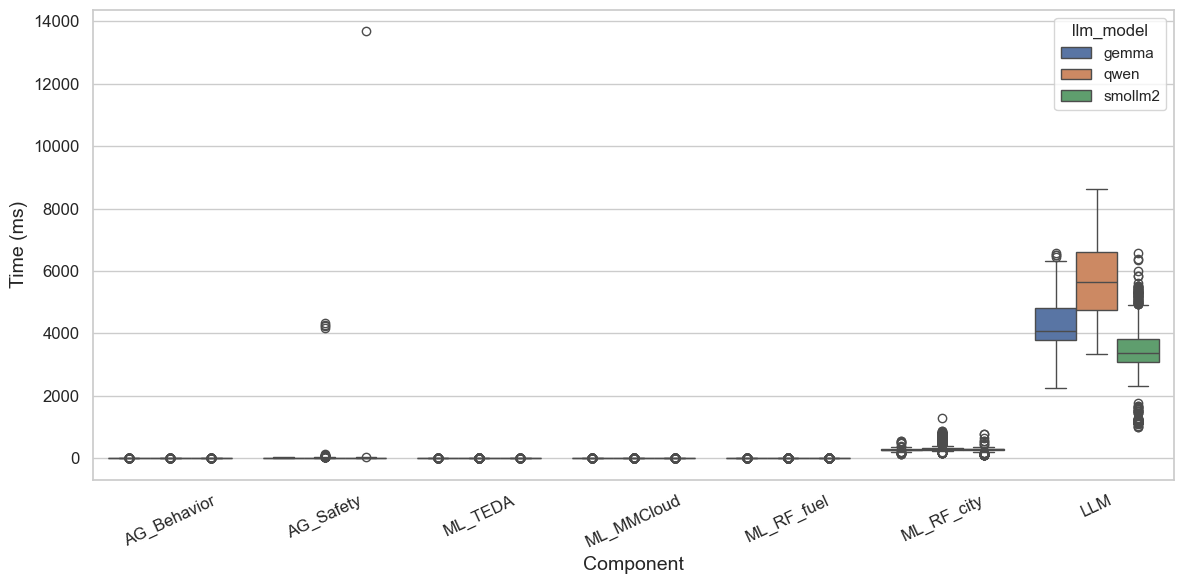

In [73]:
from helpers.emissions_stats import build_aligned_plot_data

df_time_source = build_aligned_plot_data()

df_time_all_primary = pd.concat([
    df_time_source[["model", "m.agent.behavior.wall_ms"]]
    .rename(columns={"model": "llm_model", "m.agent.behavior.wall_ms": "time_ms"})
    .assign(bloco="AG_Behavior"),
    df_time_source[["model", "m.agent.safety_gps.wall_ms"]]
    .rename(columns={"model": "llm_model", "m.agent.safety_gps.wall_ms": "time_ms"})
    .assign(bloco="AG_Safety"),
    df_time_source[["model", "m.teda.run.wall_ms"]]
    .rename(columns={"model": "llm_model", "m.teda.run.wall_ms": "time_ms"})
    .assign(bloco="ML_TEDA"),
    df_time_source[["model", "m.mmcloud.process_point.wall_ms"]]
    .rename(columns={"model": "llm_model", "m.mmcloud.process_point.wall_ms": "time_ms"})
    .assign(bloco="ML_MMCloud"),
    df_time_source[["model", "m.rf.fuel_type.wall_ms"]]
    .rename(columns={"model": "llm_model", "m.rf.fuel_type.wall_ms": "time_ms"})
    .assign(bloco="ML_RF_fuel"),
    df_time_source[["model", "m.rf.city_highway.wall_ms"]]
    .rename(columns={"model": "llm_model", "m.rf.city_highway.wall_ms": "time_ms"})
    .assign(bloco="ML_RF_city"),
    df_time_source[["model", "llm_total_ms_client"]]
    .rename(columns={"model": "llm_model", "llm_total_ms_client": "time_ms"})
    .assign(bloco="LLM"),
], ignore_index=True)

plt.figure(figsize=(12,6))
ax = sns.boxplot(data=df_time_all_primary, x="bloco", y="time_ms", hue="llm_model")
ax.set_xlabel("Component", fontsize=14)
ax.set_ylabel("Time (ms)", fontsize=14)
ax.tick_params(axis="x", labelsize=12, rotation=25)
ax.tick_params(axis="y", labelsize=12)
ax.legend(title="llm_model", title_fontsize=12, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "time_pipeline_boxplot_7blocks.png")
plt.show()

In [74]:
df_tps_mean = (
    df_time_source.groupby("model", as_index=False)["llm_tps"]
    .mean()
    .rename(columns={"model": "llm_model", "llm_tps": "mean_tokens_per_second"})
)

df_tps_mean["mean_tokens_per_second"] = df_tps_mean["mean_tokens_per_second"].round(3)

print("Mean tokens per second by model")
display(df_tps_mean)


Mean tokens per second by model


,llm_model,mean_tokens_per_second
0,gemma,6.147
1,qwen,5.203
2,smollm2,7.724


In [75]:
# Global display format for readability
pd.options.display.float_format = "{:,.3f}".format

# Column-specific rounding
df_times_desc = (
    df_time_all
    .groupby(["bloco", "llm_model"])["time_ms"]
    .describe()
    .reset_index()
)

# Arredonda a quantidade certa de casas
df_times_desc["mean"] = df_times_desc["mean"].round(3)
df_times_desc["std"] = df_times_desc["std"].round(3)
df_times_desc["min"] = df_times_desc["min"].round(3)
df_times_desc["25%"] = df_times_desc["25%"].round(3)
df_times_desc["50%"] = df_times_desc["50%"].round(3)
df_times_desc["75%"] = df_times_desc["75%"].round(3)
df_times_desc["max"] = df_times_desc["max"].round(3)

print("Statistical summary of the execution time")
display(df_times_desc)

Statistical summary of the execution time


,bloco,llm_model,count,mean,std,min,25%,50%,75%,max
0,AG_Behavior,gemma,"6,262.000",0.071,0.198,0.016,0.031,0.045,0.072,6.152
1,AG_Behavior,qwen,"6,262.000",0.091,0.208,0.017,0.042,0.061,0.095,5.704
2,AG_Behavior,smollm2,"6,262.000",0.066,0.166,0.015,0.031,0.044,0.067,5.504
3,AG_Safety,gemma,"6,262.000",14.727,12.746,0.005,6.517,9.534,20.722,103.218
4,AG_Safety,qwen,"6,262.000",23.885,159.707,0.005,7.528,10.740,23.228,"4,626.353"
5,AG_Safety,smollm2,"6,262.000",16.108,173.820,0.005,6.475,9.195,19.514,"13,681.077"
6,LLM,gemma,973.000,"4,303.540",774.362,"2,261.000","3,790.000","4,086.000","4,828.000","6,583.000"
7,LLM,qwen,"1,060.000","5,721.079","1,153.136","3,330.000","4,750.750","5,650.500","6,622.250","8,643.000"
8,LLM,smollm2,961.000,"3,442.031",875.303,994.000,"3,076.000","3,369.000","3,812.000","6,574.000"
9,ML_MMCloud,gemma,"6,262.000",0.838,1.479,0.096,0.231,0.337,0.663,12.783


## Tokens

In [76]:
# Filter only rows where the LLM actually produced a response
df_llm = df_all[df_all["llm_total_tokens"].notna()].copy()

# Ensure numeric types
numeric_cols = [
    "llm_total_tokens",
    "llm_input_tokens",
    "llm_output_tokens",
    "llm_total_ms_client",
]
df_llm[numeric_cols] = df_llm[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Remove rows with missing or invalid timing
df_llm = df_llm[df_llm["llm_total_ms_client"] > 0]

# Tokens per second based only on generated output tokens.
df_llm["llm_tps"] = df_llm["llm_output_tokens"] / (df_llm["llm_total_ms_client"] / 1000)

# Total tokens per second (input + output) to separate short responses from faster end-to-end processing.
df_llm["llm_tps_total"] = df_llm["llm_total_tokens"] / (df_llm["llm_total_ms_client"] / 1000)

# Expansion ratio: output_tokens / input_tokens
df_llm["out_in_ratio"] = df_llm["llm_output_tokens"] / df_llm["llm_input_tokens"]
df_llm.loc[~np.isfinite(df_llm["out_in_ratio"]), "out_in_ratio"] = np.nan  # guard against inf

df_llm.head(10)

,row_id,ts,Unnamed: 0.1,Unnamed: 0,timestamp,speed,rpm,engine_load,coolant_temp,timing_advance,intake_temp,throttle,fuel_level,latitude,longitude,accel_x,accel_y,accel_z,driver_behavior,teda_flag,teda_inference_time,fuel_type,fuel_type_prob,fuel_type_inference_time,mmcloud_inference_time,eco,tipoVia,tipoVia_prob,city_highway_inference_time,instant_fuel_consumption,distancia,consumo_total,consumo_medio,notaImetro,tempAmbiente,radar_area,temp_rasp,radar_area_original,has_acidente,has_multa,ground_truth,_ts_float,maf,road_type,gyro_z_dps,gyro_x,gyro_y,gyro_z,accel_magnitude,city_highway_int,city_highway_prob,city_highway,maf_estimated,co2_emission,co2_emission_per_km,total_distance,total_consumption,consumption_count,average_consumption,heading,m.teda.run.ok,m.teda.run.wall_ms,m.teda.run.cpu_user_s,m.teda.run.cpu_sys_s,m.teda.run.thread_cpu_s,m.teda.run.rss_mb,m.teda.run.mem_pct,m.mmcloud.process_point.ok,m.mmcloud.process_point.wall_ms,m.mmcloud.process_point.cpu_user_s,m.mmcloud.process_point.cpu_sys_s,m.mmcloud.process_point.thread_cpu_s,m.mmcloud.process_point.rss_mb,m.mmcloud.process_point.mem_pct,m.rf.fuel_type.ok,m.rf.fuel_type.wall_ms,m.rf.fuel_type.cpu_user_s,m.rf.fuel_type.cpu_sys_s,m.rf.fuel_type.thread_cpu_s,m.rf.fuel_type.rss_mb,m.rf.fuel_type.mem_pct,m.rf.city_highway.ok,m.rf.city_highway.wall_ms,m.rf.city_highway.cpu_user_s,m.rf.city_highway.cpu_sys_s,m.rf.city_highway.thread_cpu_s,m.rf.city_highway.rss_mb,m.rf.city_highway.mem_pct,policy_behavior,policy_severity,m.agent.behavior.ok,m.agent.behavior.wall_ms,m.agent.behavior.cpu_user_s,m.agent.behavior.cpu_sys_s,m.agent.behavior.thread_cpu_s,m.agent.behavior.rss_mb,m.agent.behavior.mem_pct,m.agent.safety_gps.ok,m.agent.safety_gps.wall_ms,m.agent.safety_gps.cpu_user_s,m.agent.safety_gps.cpu_sys_s,m.agent.safety_gps.thread_cpu_s,m.agent.safety_gps.rss_mb,m.agent.safety_gps.mem_pct,heading_message,orch_run_ms,orch_llm_enqueue_ms,llm_message,llm_source,llm_latency,llm_total_tokens,llm_input_tokens,llm_output_tokens,llm_total_ms_client,llm_cpu_avg_pct,llm_cpu_max_pct,llm_rss_peak_mb,llm_proc_samples,llm_proc_pid,llm_metrics_source,llm_agent_inserted_behavior_prf,model,vehicle,Device,Usuario,SessionDate,TimeSensor,Vin,Magnitude,TedaFlag,RadarArea,DriverBehaviour,CityRoadLabel,CityRoadProb,FuelType,FuelPredictionProbability,FuelModelPredictionTime(microseconds),TedaModelPredictionTime(microseconds),DriveBehaviourModelPredictionTime(microseconds),CityRoadModelPredictionTime(microseconds),TimesDisconnected,ReconnectionCount,EngineOilTemp,battery,FuelPressure,FuelRailPressure,fuel_rail_pressure,map,runtime,distance_mil,ethanol_percentage,relative_throttle,acc_pedal_d,acc_pedal_e,absolute_throttle_b,catalyst_temp_b1s1,fuel_rate,absolute_load,air_fuel_ratio,baro_pressure,llm_tps,llm_tps_total,out_in_ratio
0,1,2025-12-04T21:01:58.703262+00:00,0.000,0.000,2025-07-01T19:39:40.300056,0.000,871.000,32.000,70.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.275,-0.171,9.805,normal,False,0.026,Gasoline,1.000,184.443,0.000,False,Cidade,[0.62 0.38],631.524,0.000,0.000,3.021,3.021,A,28.500,139.360,59.300,139.360,False,False,nenhum,NaN,NaN,NaN,0.000,2.271,2.298,-1.581,9.810,0.000,[0.6 0.4],City,False,0.000,0.000,0.000,0.000,1,0.000,N,True,0.026,0.000,0.000,0.000,229.480,2.850,True,0.121,0.000,0.000,0.000,229.480,2.850,True,0.006,0.000,0.000,0.000,229.480,2.850,True,179.192,0.127,0.052,0.179,243.950,3.030,Cautious,low,True,0.043,0.000,0.000,0.000,243.950,3.030,True,4.020,0.004,0.000,0.004,243.950,3.030,NaN,4.340,0.031,Behavior: Cautious. PRF zone: none. Draft: Dri...,model,NaN,115.000,89.000,26.000,"6,308.000",130.908,307.500,654.141,62.000,"22,630.000",server+client,True,gemma,eclipse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.122,18.231,0.292
7,8,2025-12-04T21:02:11.418566+00:00,7.000,7.000,2025-07-01T19:40:04.103013,0.000,871.000,32.000,71.000,-1.000,0.000,16.000,97.650,-5.843,-35.198,-0

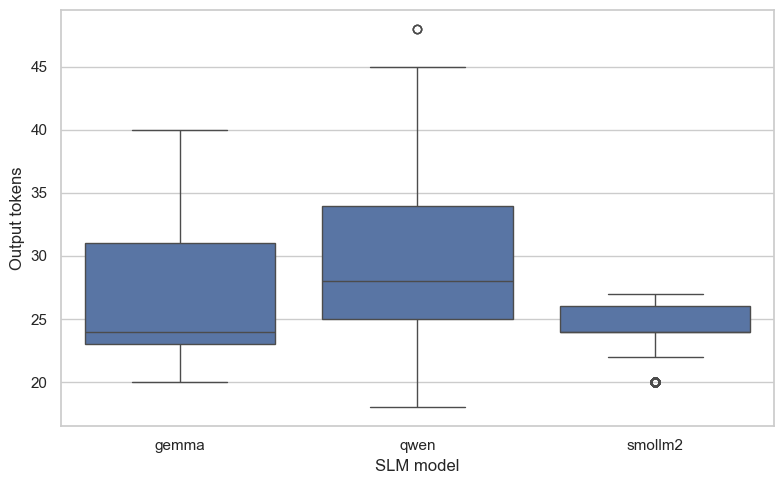

Statistical summary – output tokens:
            count   mean   std    min    25%    50%    75%    max
model                                                            
gemma     973.000 26.000 3.590 20.000 23.000 24.000 31.000 40.000
qwen    1,060.000 29.660 6.350 18.000 25.000 28.000 34.000 48.000
smollm2   961.000 24.060 1.780 20.000 24.000 24.000 26.000 27.000


In [77]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_llm, x="model", y="llm_output_tokens")
plt.xlabel("SLM model")
plt.ylabel("Output tokens")
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "llm_output_tokens_boxplot.png")
plt.show()

print("Statistical summary – output tokens:")
print(df_llm.groupby("model")["llm_output_tokens"].describe().round(2))

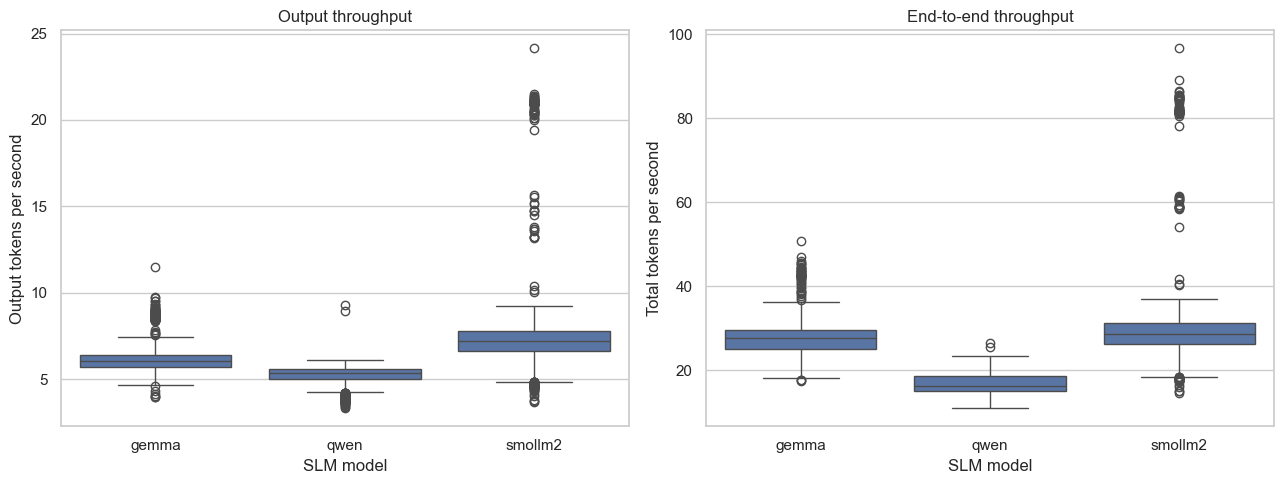

Statistical summary – output tokens per second:
            count  mean   std   min   25%   50%   75%    max
model                                                       
gemma     973.000 6.150 0.920 3.950 5.680 6.050 6.380 11.500
qwen    1,060.000 5.200 0.570 3.310 5.020 5.360 5.560  9.290
smollm2   961.000 7.720 3.430 3.650 6.600 7.180 7.790 24.140

Statistical summary – total tokens per second:
            count   mean    std    min    25%    50%    75%    max
model                                                             
gemma     973.000 27.630  4.820 17.470 25.050 27.600 29.600 50.860
qwen    1,060.000 16.690  2.380 10.990 15.020 16.310 18.660 26.510
smollm2   961.000 30.990 13.660 14.600 26.170 28.670 31.320 96.580


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

sns.boxplot(data=df_llm, x="model", y="llm_tps", ax=axes[0])
axes[0].set_xlabel("SLM model")
axes[0].set_ylabel("Output tokens per second")
axes[0].set_title("Output throughput")

sns.boxplot(data=df_llm, x="model", y="llm_tps_total", ax=axes[1])
axes[1].set_xlabel("SLM model")
axes[1].set_ylabel("Total tokens per second")
axes[1].set_title("End-to-end throughput")

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "llm_tps_boxplot.png")
plt.show()

print("Statistical summary – output tokens per second:")
print(df_llm.groupby("model")["llm_tps"].describe().round(2))
print()
print("Statistical summary – total tokens per second:")
print(df_llm.groupby("model")["llm_tps_total"].describe().round(2))

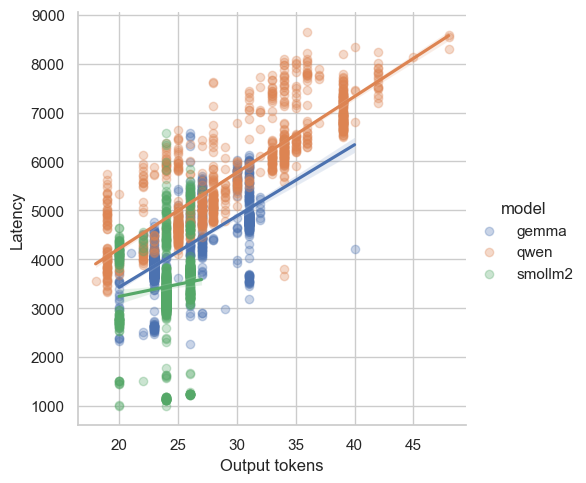

In [79]:
sns.lmplot(
    data=df_llm,
    x="llm_output_tokens",
    y="llm_total_ms_client",
    hue="model",
    scatter_kws={"alpha":0.3}
)
# plt.title("Correlation between answer's lenght and latency")
plt.xlabel("Output tokens")
plt.ylabel("Latency")
plt.show()

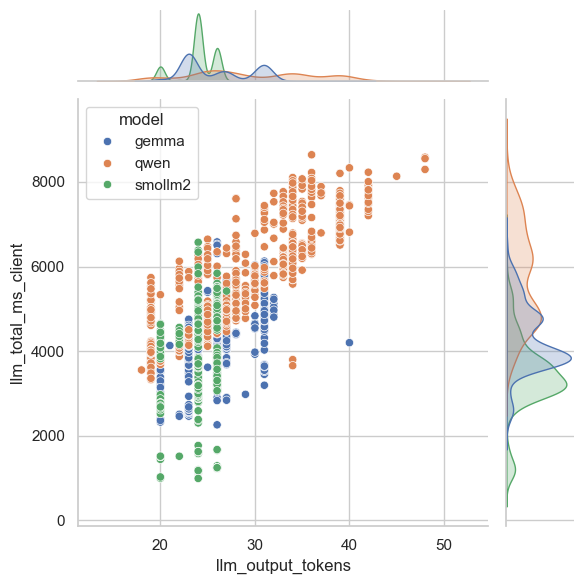

In [80]:
sns.jointplot(
    data=df_llm,
    x="llm_output_tokens",
    y="llm_total_ms_client",
    hue="model",
    kind="scatter",
    height=6
)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "latency_vs_output_tokens.png")
plt.show()

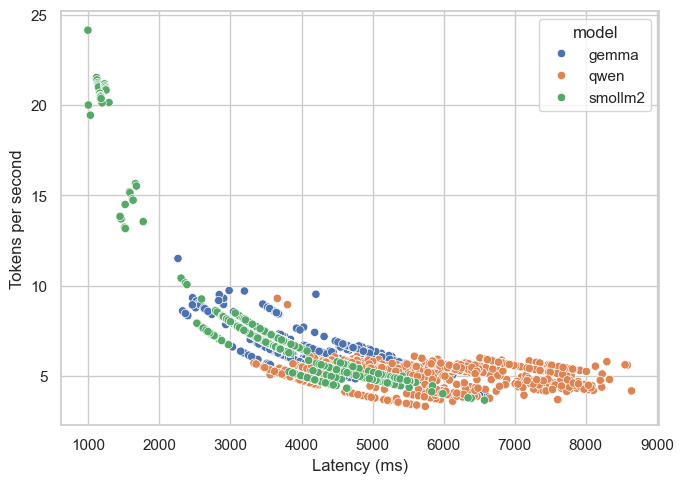

In [81]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_llm,
    x="llm_total_ms_client",
    y="llm_tps",
    hue="model"
)
plt.xlabel("Latency (ms)")
plt.ylabel("Tokens per second")
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "efficiency_latency_vs_tps.png")
plt.show()

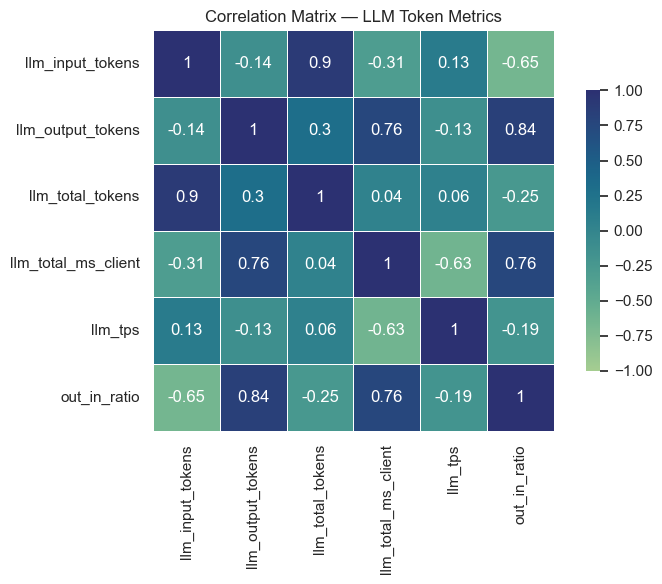

In [82]:
# Select numerical token & latency metrics
corr_cols = [
    "llm_input_tokens",
    "llm_output_tokens",
    "llm_total_tokens",
    "llm_total_ms_client",
    "llm_tps",
    "out_in_ratio",
]

df_corr = df_llm[corr_cols].corr().round(2)

plt.figure(figsize=(8,6))
sns.heatmap(
    df_corr,
    annot=True,
    cmap="crest",     # nice scientific palette
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Matrix — LLM Token Metrics", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "llm_token_correlation_matrix.png", dpi=300)
plt.show()

In [83]:
# Repeated-measures statistical analysis by vehicle
STAT_BLOCK = "vehicle"
STAT_MODEL = "model"


def run_statistical_workflow(df, metric, aggfunc="median", alpha=0.05):
    pivot = aggregate_metric_by_block(
        df=df,
        metric=metric,
        block_col=STAT_BLOCK,
        model_col=STAT_MODEL,
        aggfunc=aggfunc,
    )

    print(f"\n=== {metric} | aggregated by {STAT_BLOCK} using {aggfunc} ===")
    display(pivot)

    if pivot.shape[1] < 3 or pivot.shape[0] == 0:
        print("\nSkipping statistical tests: metric does not have enough complete data across all models/vehicles.")
        return pivot

    print("\nShapiro-Wilk on aggregated values (diagnostic only):")
    display(shapiro_tests_by_model(pivot, alpha=alpha))

    friedman_results = friedman_test(pivot, alpha=alpha)
    print("\nFriedman global test:")
    display(pd.DataFrame([friedman_results]))

    if friedman_results["p_value"] < alpha:
        print("\nPairwise Wilcoxon post-hoc with Holm correction:")
        display(pairwise_wilcoxon_tests(pivot, alpha=alpha))
    else:
        print("\nPost-hoc skipped because Friedman was not significant.")

    return pivot


In [84]:
df_codecarbon_plot = build_aligned_plot_data()

emissions_stat_sources = {
    "llm_total_ms_client": df_llm,
    "llm_output_tokens": df_llm,
    "llm_tps": df_llm,
    "energy_consumed": df_codecarbon_plot,
    "emissions": df_codecarbon_plot,
}

emissions_stat_results = {}
for metric, metric_df in emissions_stat_sources.items():
    emissions_stat_results[metric] = run_statistical_workflow(metric_df, metric)



=== llm_total_ms_client | aggregated by vehicle using median ===


model,gemma,qwen,smollm2
vehicle,,,
eclipse,"4,121.000","5,587.000","1,228.000"
etios,"4,671.000","5,756.000","3,580.000"
fastback,"4,436.500","5,565.000","3,499.000"
fit,"3,671.000","5,702.000","3,380.000"
hb20,"3,981.500","5,358.000","3,356.000"
polo_silver,"4,619.000","5,667.000","3,744.000"
polo_white,"4,322.000","5,947.000","3,578.500"
prisma,"3,955.000","5,577.000","3,325.000"
renegade,"4,043.000","5,275.000","3,321.000"



Shapiro-Wilk on aggregated values (diagnostic only):


,model,statistic,p_value,is_normal
0,gemma,0.940,0.558,True
1,qwen,0.956,0.738,True
2,smollm2,0.555,0.000,False



Friedman global test:


...

,model,statistic,p_value,is_normal
0,gemma,0.899,0.211,True
1,qwen,0.888,0.160,True
2,smollm2,0.468,0.000,False



Friedman global test:


,statistic,p_value,is_significant,kendalls_w,n_blocks,n_models
0,18.200,0.000,True,0.910,10,3



Pairwise Wilcoxon post-hoc with Holm correction:


,model_a,model_b,statistic,p_value,rank_biserial,a12,p_value_holm,is_significant
0,gemma,qwen,0.000,0.002,-1.000,0.000,0.006,True
1,qwen,smollm2,0.000,0.002,1.000,1.000,0.006,True
2,gemma,smollm2,1.000,0.004,0.964,0.910,0.006,True


In [85]:
# Independent-groups statistical analysis by model
def run_independent_statistical_workflow(df, metric, alpha=0.05):
    metric_df = df[["model", metric]].dropna().copy()

    print(f"\n=== {metric} | independent-groups analysis ===")
    display(
        metric_df.groupby("model")[metric].describe()
    )

    print("\nKruskal-Wallis global test:")
    kruskal_results = kruskal_wallis_test(metric_df, metric=metric, model_col="model", alpha=alpha)
    display(pd.DataFrame([kruskal_results]))

    if kruskal_results["p_value"] < alpha:
        print("\nDunn post-hoc with Bonferroni correction:")
        display(pairwise_dunn_tests(metric_df, metric=metric, model_col="model", alpha=alpha))
    else:
        print("\nPost-hoc skipped because Kruskal-Wallis was not significant.")

    return metric_df


In [86]:
df_codecarbon_plot = build_aligned_plot_data()

emissions_independent_stat_sources = {
    "llm_total_ms_client": df_llm,
    "llm_output_tokens": df_llm,
    "llm_tps": df_llm,
    "energy_consumed": df_codecarbon_plot,
    "emissions": df_codecarbon_plot,
}

emissions_independent_stat_results = {}
for metric, metric_df in emissions_independent_stat_sources.items():
    emissions_independent_stat_results[metric] = run_independent_statistical_workflow(metric_df, metric)



=== llm_total_ms_client | independent-groups analysis ===


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
gemma,973.000,"4,303.540",774.362,"2,261.000","3,790.000","4,086.000","4,828.000","6,583.000"
qwen,"1,060.000","5,721.079","1,153.136","3,330.000","4,750.750","5,650.500","6,622.250","8,643.000"
smollm2,961.000,"3,442.031",875.303,994.000,"3,076.000","3,369.000","3,812.000","6,574.000"



Kruskal-Wallis global test:


,statistic,p_value,is_significant,n_models,n_observations
0,"1,596.028",0.000,True,3,2994



Dunn post-hoc with Bonferroni correction:


...

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
gemma,973.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
qwen,"1,060.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
smollm2,961.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000



Kruskal-Wallis global test:


,statistic,p_value,is_significant,n_models,n_observations
0,"1,406.469",0.000,True,3,2994



Dunn post-hoc with Bonferroni correction:


,model_a,model_b,z_value,p_value,cliffs_delta,p_value_bonferroni,is_significant
0,qwen,smollm2,36.682,0.000,0.865,0.000,True
1,gemma,qwen,-24.358,0.000,-0.702,0.000,True
2,gemma,smollm2,12.148,0.000,0.405,0.000,True


## 🧠 Statistical Interpretation

This notebook combines the processed experiment snapshot with the aligned CodeCarbon measurements to support the final quantitative results reported in the article.

- **Latency (`llm_total_ms_client`)**: `qwen` is the fastest model, `smollm2` is intermediate, and `gemma` is the slowest.
- **Output tokens (`llm_output_tokens`)**: `qwen` tends to produce shorter completions than the other models.
- **Throughput (`llm_tps`)**: because this metric uses output tokens only, `smollm2` achieves the highest output-token throughput, `gemma` is intermediate, and `qwen` is lowest.
- **Energy consumption (`energy_consumed`)** and **emissions (`emissions`)**: `qwen` has the highest environmental cost, `gemma` is intermediate, and `smollm2` is the most efficient.

Taken together, the results show that lower latency does not automatically imply better throughput or lower environmental impact, because completion length and per-inference cost vary substantially across models. 📊


In [87]:
# Clean message column (important!)
df_llm["llm_message_clean"] = (
    df_llm["llm_message"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# --- Unique answer count per model ---
unique_counts = df_llm.groupby("model")["llm_message_clean"].nunique()

# --- Total answers per model ---
total_counts = df_llm.groupby("model")["llm_message_clean"].count()

# --- Repetition rate (1 = everything repeated, 0 = everything unique) ---
repetition_rate = (1 - unique_counts / total_counts).round(3)

# Final table
df_msg_stats = pd.DataFrame({
    "Total answers": total_counts,
    "Unique answers": unique_counts,
    "Repetition rate": repetition_rate
}).sort_index()

display(df_msg_stats)

,Total answers,Unique answers,Repetition rate
model,,,
gemma,973,24,0.975
qwen,1060,104,0.902
smollm2,961,8,0.992


In [88]:
df_all.llm_agent_inserted_behavior_prf.value_counts()

llm_agent_inserted_behavior_prf
False    2393
True      601
Name: count, dtype: int64

In [89]:
# Use your cleaned dataframe
df_corr = df_all.copy()

# Keep only rows where correction information exists
df_corr = df_corr[df_corr["llm_agent_inserted_behavior_prf"].notna()]

# Count corrections per model
corrections_per_model = (
    df_corr[df_corr["llm_agent_inserted_behavior_prf"] == True]
    .groupby("model")
    .size()
    .rename("corrections")
)

# Total LLM calls per model (only where correction flag exists)
total_calls = (
    df_corr
    .groupby("model")["llm_agent_inserted_behavior_prf"]
    .count()
    .rename("total_calls")
)

# Correction rate: how often the agent had to fix the answer
correction_rate = (corrections_per_model / total_calls).round(3)

df_correction_stats = pd.concat(
    [corrections_per_model, total_calls, correction_rate.rename("correction_rate")],
    axis=1
).fillna(0)

display(df_correction_stats)

,corrections,total_calls,correction_rate
model,,,
gemma,123.000,973,0.126
qwen,478.000,1060,0.451
smollm2,0.000,961,0.000


Do slower models produce better answers?
Do faster models need more corrections?

<Axes: xlabel='avg_latency', ylabel='correction_rate'>

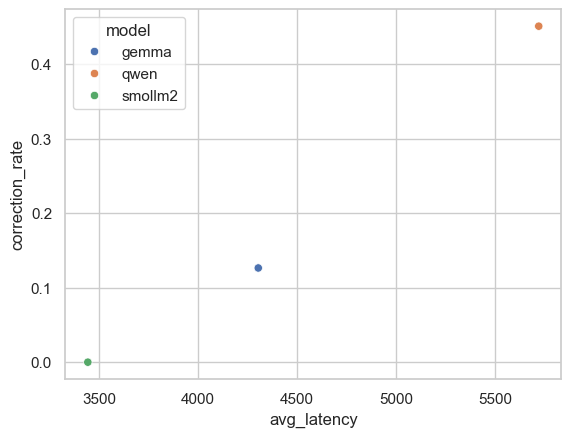

In [90]:
df_tmp = (
    df_llm.groupby("model")
    .agg(correction_rate=("llm_agent_inserted_behavior_prf", "mean"),
         avg_latency=("llm_total_ms_client", "mean"))
)
sns.scatterplot(data=df_tmp, x="avg_latency", y="correction_rate", hue=df_tmp.index)

<Axes: xlabel='llm_tps', ylabel='llm_cpu_avg_pct'>

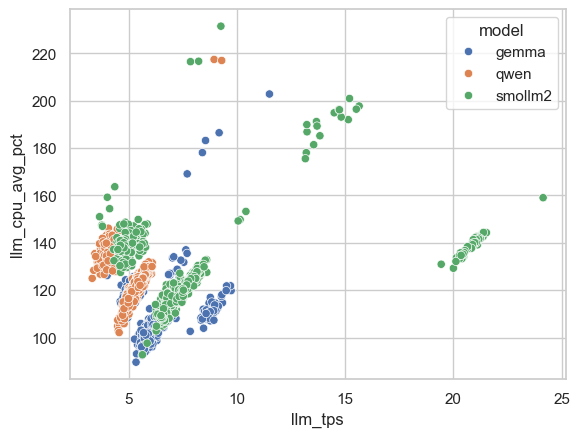

In [91]:
sns.scatterplot(x="llm_tps", y="llm_cpu_avg_pct", hue="model", data=df_llm)

## 🌱 Energy and Emissions


In [92]:

df_codecarbon_plot = build_aligned_plot_data()
df_codecarbon_plot["model"] = pd.Categorical(
    df_codecarbon_plot["model"],
    categories=["gemma", "qwen", "smollm2"],
    ordered=True,
)

df_codecarbon_plot[["model", "vehicle", "energy_consumed", "emissions"]].head()

,model,vehicle,energy_consumed,emissions
0,gemma,eclipse,0.000,0.000
1,gemma,eclipse,0.000,0.000
2,gemma,eclipse,0.000,0.000
3,gemma,eclipse,0.000,0.000
4,gemma,eclipse,0.000,0.000


In [93]:
print("Rows with energy values:", df_codecarbon_plot["energy_consumed"].notna().sum())
print("Rows with emissions values:", df_codecarbon_plot["emissions"].notna().sum())

Rows with energy values: 2994
Rows with emissions values: 2994


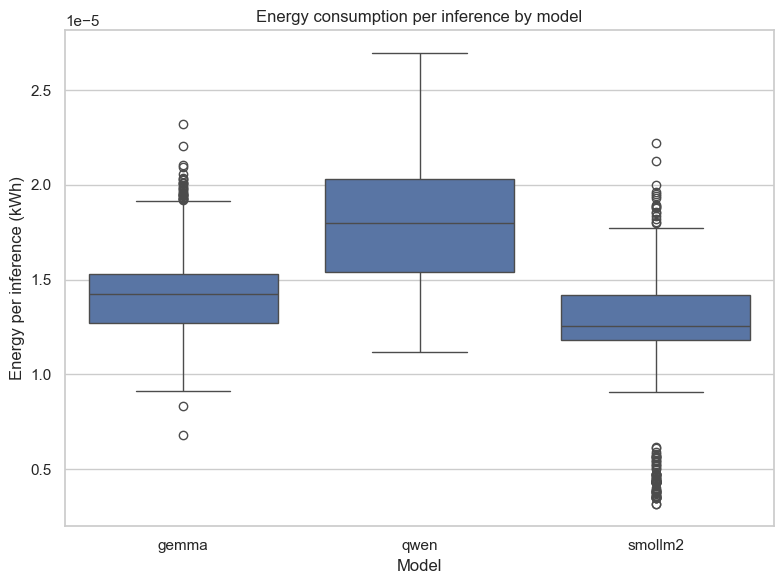

In [94]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_codecarbon_plot,
    x="model",
    y="energy_consumed"
)

plt.xlabel("Model")
plt.ylabel("Energy per inference (kWh)")
plt.title("Energy consumption per inference by model")
plt.tight_layout()
plt.show()

/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/697745332.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/morsinaldo/miniconda3/envs/agent/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


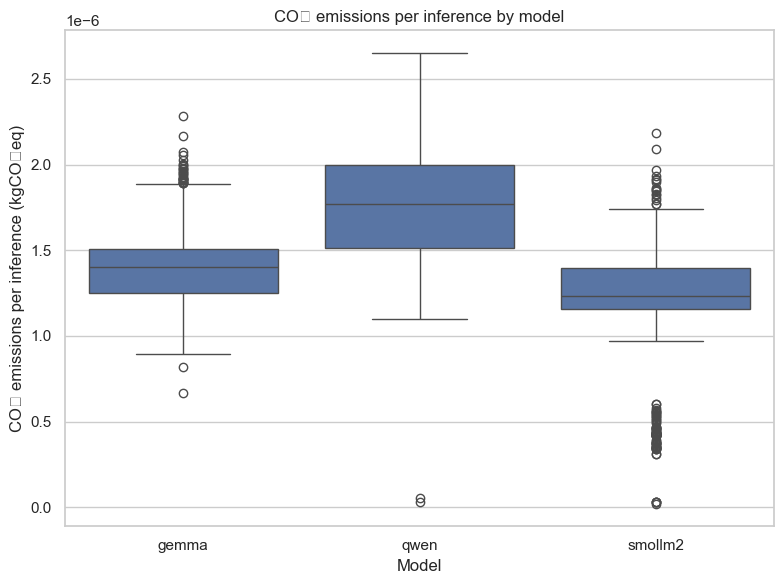

In [95]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_codecarbon_plot,
    x="model",
    y="emissions"
)

plt.xlabel("Model")
plt.ylabel("CO₂ emissions per inference (kgCO₂eq)")
plt.title("CO₂ emissions per inference by model")
plt.tight_layout()
plt.show()

/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/100656810.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("model", as_index=False)["energy_consumed"]


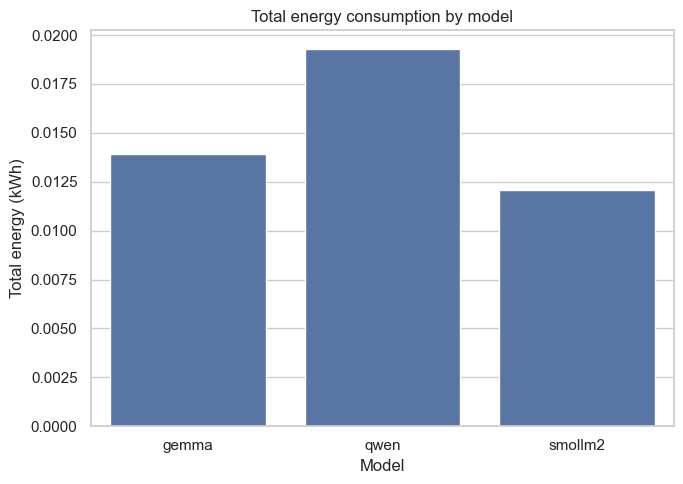

In [96]:
energy_total = (
    df_codecarbon_plot
    .groupby("model", as_index=False)["energy_consumed"]
    .sum()
)

plt.figure(figsize=(7,5))
sns.barplot(
    data=energy_total,
    x="model",
    y="energy_consumed"
)

plt.xlabel("Model")
plt.ylabel("Total energy (kWh)")
plt.title("Total energy consumption by model")
plt.tight_layout()
plt.show()

In [97]:
stats_model = (
    df_codecarbon_plot
    .groupby("model")
    .agg(
        n_inferences = ("energy_consumed", "count"),

        # energia
        energy_mean  = ("energy_consumed", "mean"),
        energy_std   = ("energy_consumed", "std"),
        energy_median= ("energy_consumed", "median"),
        energy_min   = ("energy_consumed", "min"),
        energy_max   = ("energy_consumed", "max"),
        energy_sum   = ("energy_consumed", "sum"),

        # emissões
        emissions_mean  = ("emissions", "mean"),
        emissions_std   = ("emissions", "std"),
        emissions_median= ("emissions", "median"),
        emissions_min   = ("emissions", "min"),
        emissions_max   = ("emissions", "max"),
        emissions_sum   = ("emissions", "sum"),
    )
    .reset_index()
)

stats_model

/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/3036475380.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("model")


,model,n_inferences,energy_mean,energy_std,energy_median,energy_min,energy_max,energy_sum,emissions_mean,emissions_std,emissions_median,emissions_min,emissions_max,emissions_sum
0,gemma,973,0.000,0.000,0.000,0.000,0.000,0.014,0.000,0.000,0.000,0.000,0.000,0.001
1,qwen,1060,0.000,0.000,0.000,0.000,0.000,0.019,0.000,0.000,0.000,0.000,0.000,0.002
2,smollm2,961,0.000,0.000,0.000,0.000,0.000,0.012,0.000,0.000,0.000,0.000,0.000,0.001


/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/199418918.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("model", as_index=False)["emissions"]
/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/199418918.py:17: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/morsinaldo/miniconda3/envs/agent/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


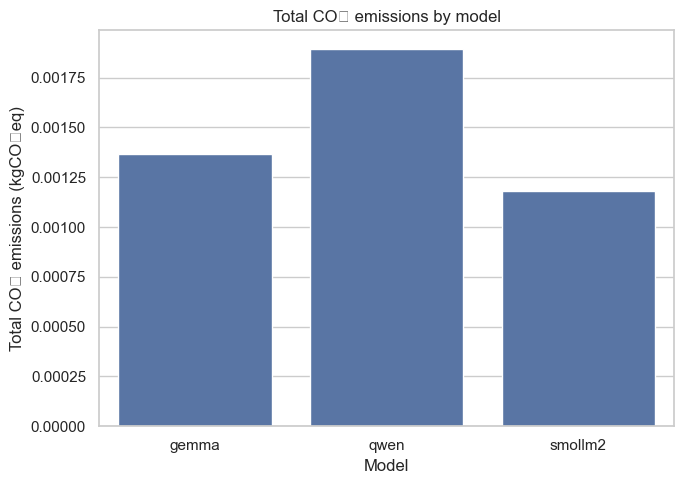

In [98]:
emissions_total = (
    df_codecarbon_plot
    .groupby("model", as_index=False)["emissions"]
    .sum()
)

plt.figure(figsize=(7,5))
sns.barplot(
    data=emissions_total,
    x="model",
    y="emissions"
)

plt.xlabel("Model")
plt.ylabel("Total CO₂ emissions (kgCO₂eq)")
plt.title("Total CO₂ emissions by model")
plt.tight_layout()
plt.show()

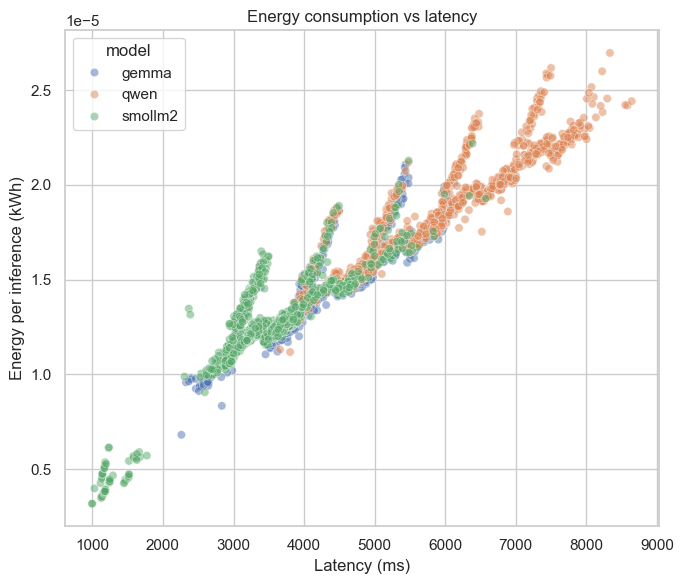

In [99]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df_codecarbon_plot,
    x="llm_total_ms_client",
    y="energy_consumed",
    hue="model",
    alpha=0.5
)

plt.xlabel("Latency (ms)")
plt.ylabel("Energy per inference (kWh)")
plt.title("Energy consumption vs latency")
plt.tight_layout()
plt.show()

/Users/morsinaldo/miniconda3/envs/agent/lib/python3.11/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/morsinaldo/miniconda3/envs/agent/lib/python3.11/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/morsinaldo/miniconda3/envs/agent/lib/python3.11/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


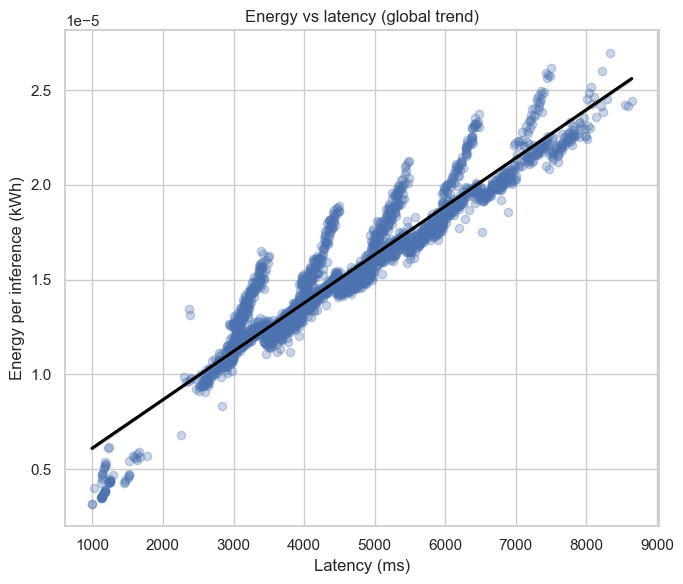

In [100]:
plt.figure(figsize=(7,6))
sns.regplot(
    data=df_codecarbon_plot,
    x="llm_total_ms_client",
    y="energy_consumed",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "black"}
)

plt.xlabel("Latency (ms)")
plt.ylabel("Energy per inference (kWh)")
plt.title("Energy vs latency (global trend)")
plt.tight_layout()
plt.show()

/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/2282008469.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model", "component"], as_index=False)["energy"]


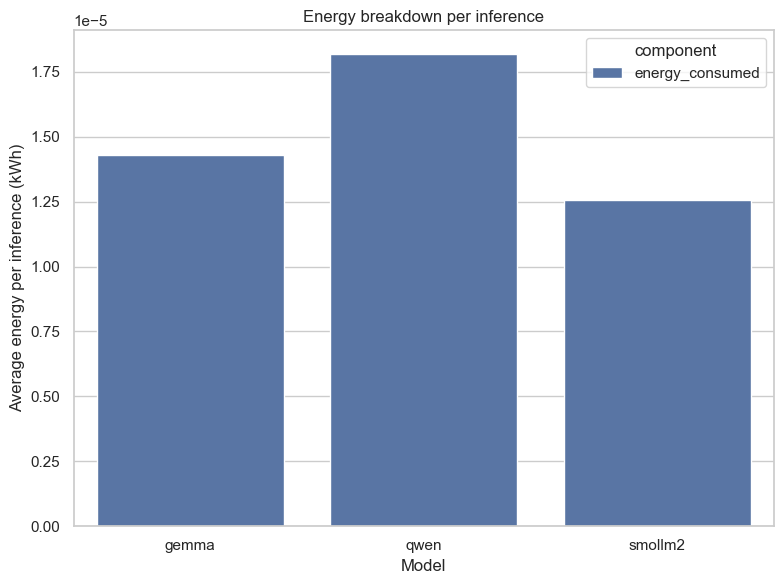

In [101]:
energy_components = [
    column for column in ["cpu_energy", "ram_energy", "gpu_energy", "energy_consumed"]
    if column in df_codecarbon_plot.columns
]

energy_long = df_codecarbon_plot.melt(
    id_vars="model",
    value_vars=energy_components,
    var_name="component",
    value_name="energy"
)

energy_mean = (
    energy_long
    .groupby(["model", "component"], as_index=False)["energy"]
    .mean()
)

plt.figure(figsize=(8,6))
sns.barplot(
    data=energy_mean,
    x="model",
    y="energy",
    hue="component"
)

plt.xlabel("Model")
plt.ylabel("Average energy per inference (kWh)")
plt.title("Energy breakdown per inference")
plt.tight_layout()
plt.show()


/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/3984196814.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


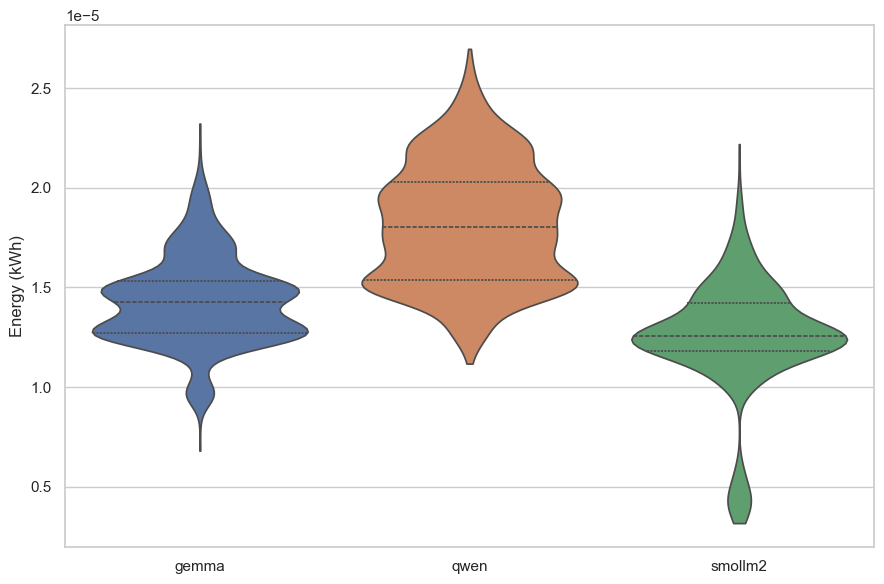

In [102]:
# Optionally drop rows without emissions or energy values for a cleaner scatter plot.
df_llm_scatter = df_codecarbon_plot.dropna(subset=["emissions", "llm_tps"]).copy()

# Fixed palette to keep model colors consistent across plots.
PALETTE = {
    "gemma":   "#4C72B0",
    "qwen":    "#DD8452",
    "smollm2": "#55A868",
}

# Keep the plotting order consistent.
MODEL_ORDER = ["gemma", "qwen", "smollm2"]
df_codecarbon_plot["model"] = pd.Categorical(df_codecarbon_plot["model"], categories=MODEL_ORDER, ordered=True)
df_llm_scatter["model"] = pd.Categorical(df_llm_scatter["model"], categories=MODEL_ORDER, ordered=True)

# -------------------------
# Figure A: violin plot of energy per inference.
# -------------------------
plt.figure(figsize=(9,6))
ax = sns.violinplot(
    data=df_codecarbon_plot,
    x="model",
    y="energy_consumed",
    order=MODEL_ORDER,
    palette=PALETTE,
    inner="quartile",
    cut=0
)
# ax.set_title("Energy per Inference")
ax.set_xlabel("")
ax.set_ylabel("Energy (kWh)")

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "energy_violin.png", dpi=300, bbox_inches="tight")
plt.show()

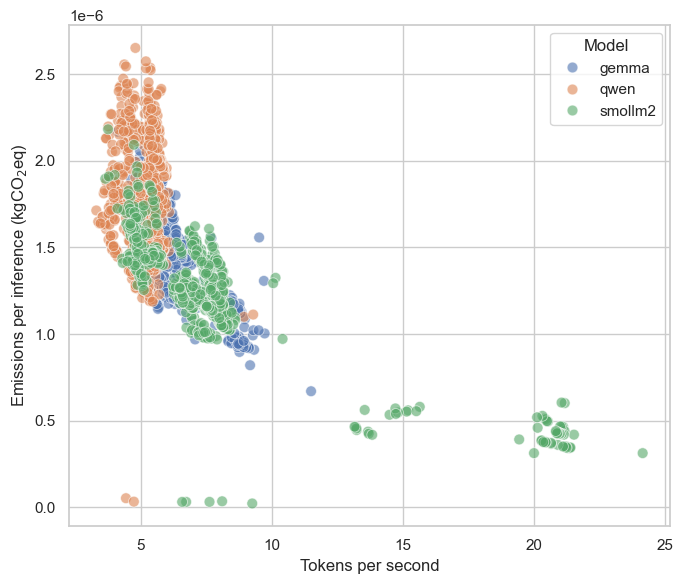

In [103]:
plt.figure(figsize=(7,6))

ax = sns.scatterplot(
    data=df_codecarbon_plot,
    x="llm_tps",
    y="emissions",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=PALETTE,
    alpha=0.6,
    s=60
)

ax.set_xlabel("Tokens per second")
ax.set_ylabel("Emissions per inference (kgCO$_2$eq)")
ax.legend(title="Model", loc="best", frameon=True)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES_DIR / "tps_vs_emissions.png", dpi=300, bbox_inches="tight")
plt.show()

In [104]:
from scipy.stats import pearsonr, spearmanr

df_corr = df_codecarbon_plot.dropna(subset=["energy_consumed", "emissions"])

pearson_r, pearson_p = pearsonr(
    df_corr["energy_consumed"],
    df_corr["emissions"]
)

spearman_r, spearman_p = spearmanr(
    df_corr["energy_consumed"],
    df_corr["emissions"]
)

print("Global correlation (Energy vs Emissions)")
print(f"Pearson r = {pearson_r:.4f} (p = {pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.4f} (p = {spearman_p:.2e})")

Global correlation (Energy vs Emissions)
Pearson r = 0.9829 (p = 0.00e+00)
Spearman ρ = 0.9970 (p = 0.00e+00)


In [105]:
for model, df_m in df_corr.groupby("model"):
    r, p = pearsonr(df_m["energy_consumed"], df_m["emissions"])
    print(f"{model:8s} | Pearson r = {r:.4f} | p = {p:.2e}")

gemma    | Pearson r = 1.0000 | p = 0.00e+00
qwen     | Pearson r = 0.9687 | p = 0.00e+00
smollm2  | Pearson r = 0.9552 | p = 0.00e+00


/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_21080/3804932673.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model, df_m in df_corr.groupby("model"):


In [106]:
df_all.heading_message.notna().value_counts()

heading_message
False    13341
True      5445
Name: count, dtype: int64

## RQ4

In [107]:
df = df_all.copy()

df_eval = df[
    df["llm_message"].notna() &
    df["heading_message"].notna()
].copy()

In [108]:
df_eval["agent_detected_event"] = df_eval["heading_message"].str.contains(
    r"accident|fine",
    case=False,
    regex=True,
    na=False
)

In [109]:
df_eval["llm_mentioned_event"] = df_eval["llm_message"].str.contains(
    r"accident|fine",
    case=False,
    regex=True,
    na=False
)

In [110]:
df_risk = df_eval[df_eval["agent_detected_event"]].copy()

In [111]:
rq4_metrics = (
    df_risk
    .groupby("model")
    .agg(
        total_risk_cases = ("agent_detected_event", "count"),
        correct_mentions = ("llm_mentioned_event", "sum")
    )
    .reset_index()
)

rq4_metrics["detection_compliance_rate"] = (
    rq4_metrics["correct_mentions"] / rq4_metrics["total_risk_cases"]
)

rq4_metrics["miss_rate"] = 1.0 - rq4_metrics["detection_compliance_rate"]

rq4_metrics

,model,total_risk_cases,correct_mentions,detection_compliance_rate,miss_rate
0,gemma,293,293,1.000,0.000
1,qwen,314,314,1.000,0.000
2,smollm2,275,275,1.000,0.000


In [112]:
corrections = (
    df_eval[df_eval["agent_detected_event"]]
    .groupby("model")["llm_agent_inserted_behavior_prf"]
    .mean()
    .reset_index(name="correction_rate")
)

rq4_metrics = rq4_metrics.merge(corrections, on="model", how="left")
rq4_metrics

,model,total_risk_cases,correct_mentions,detection_compliance_rate,miss_rate,correction_rate
0,gemma,293,293,1.000,0.000,0.072
1,qwen,314,314,1.000,0.000,0.121
2,smollm2,275,275,1.000,0.000,0.000


## 📈 Article Figures

The plots below summarize the latency, throughput, and energy patterns used in the final article figures.


## 📈 Article Figures

The article figures are already generated in the analysis sections above. This section is kept only as a marker to avoid duplicating the same plots in the notebook.


Plot already generated above.


Plot already generated above.


Plot already generated above.


## 📚 Statistical Validation Table

This section reconstructs the statistical summary table used in the article from the same data sources analyzed above.


In [117]:
stats_table = reconstruct_stats_table(DEFAULT_CONFIG)
stats_table


,Metric,H,Q vs. S,G vs. Q,G vs. S,n
0,Latency,"1,596.000",0.906,-0.677,0.593,2994
1,Output tokens,513.400,0.595,-0.367,0.107,2994
2,Throughput (TPS),"1,214.300",-0.732,0.701,-0.499,2994
3,Energy,"1,413.800",0.868,-0.705,0.402,2994
4,CO2 emissions,"1,406.500",0.865,-0.702,0.405,2994


In [118]:
reference_table = reference_stats_table()
comparison = compare_results_to_reference(DEFAULT_CONFIG)
display(reference_table)
comparison


,Metric,H,Q vs. S,G vs. Q,G vs. S
0,Latency,"1,596.000",0.906,-0.677,0.593
1,Output tokens,513.400,0.595,-0.367,0.107
2,Throughput (TPS),"1,214.300",-0.732,0.701,-0.499
3,Energy,"1,369.700",0.856,-0.695,0.394
4,CO2 emissions,"1,357.500",0.852,-0.691,0.398


,Metric,H_published,Q vs. S_published,G vs. Q_published,G vs. S_published,H_reconstructed,Q vs. S_reconstructed,G vs. Q_reconstructed,G vs. S_reconstructed,n,H delta,Q vs. S delta,G vs. Q delta,G vs. S delta
0,Latency,"1,596.000",0.906,-0.677,0.593,"1,596.000",0.906,-0.677,0.593,2994,0.000,0.000,0.000,0.000
1,Output tokens,513.400,0.595,-0.367,0.107,513.400,0.595,-0.367,0.107,2994,0.000,0.000,0.000,0.000
2,Throughput (TPS),"1,214.300",-0.732,0.701,-0.499,"1,214.300",-0.732,0.701,-0.499,2994,0.000,0.000,0.000,0.000
3,Energy,"1,369.700",0.856,-0.695,0.394,"1,413.800",0.868,-0.705,0.402,2994,44.100,0.012,-0.010,0.008
4,CO2 emissions,"1,357.500",0.852,-0.691,0.398,"1,406.500",0.865,-0.702,0.405,2994,49.000,0.013,-0.011,0.007


In [119]:
latex_ready = stats_table[["Metric", "H", "Q vs. S", "G vs. Q", "G vs. S"]].copy()
latex_ready


,Metric,H,Q vs. S,G vs. Q,G vs. S
0,Latency,"1,596.000",0.906,-0.677,0.593
1,Output tokens,513.400,0.595,-0.367,0.107
2,Throughput (TPS),"1,214.300",-0.732,0.701,-0.499
3,Energy,"1,413.800",0.868,-0.705,0.402
4,CO2 emissions,"1,406.500",0.865,-0.702,0.405
